In [2]:
import torch
from torchvision import datasets, transforms

In [8]:
data_dir1 = "/kaggle/input/fruit-recognition/test"
data_dir2 = "/kaggle/input/fruit-recognition/train/train"

In [18]:
data_test = datasets.ImageFolder(data_dir1)
data_train = datasets.ImageFolder(data_dir2)

In [11]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
     transforms.RandomRotation(10),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
     transforms.ToTensor()
    ] 
)

In [19]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [20]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [21]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

(224, 224, 3)


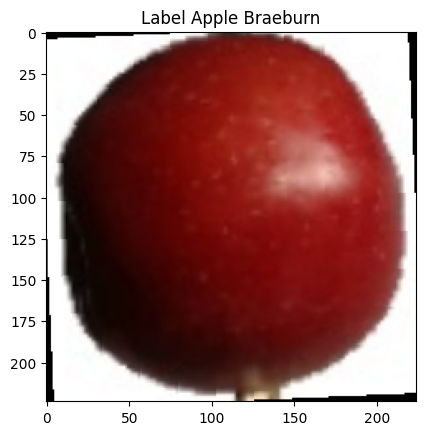

(224, 224, 3)


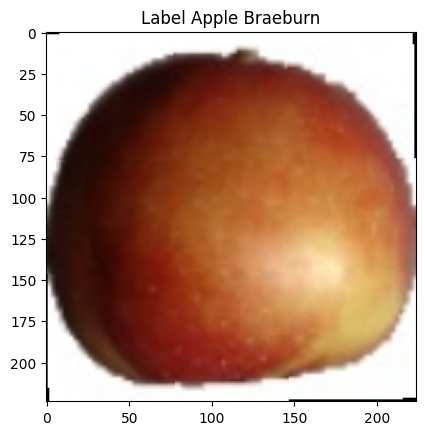

(224, 224, 3)


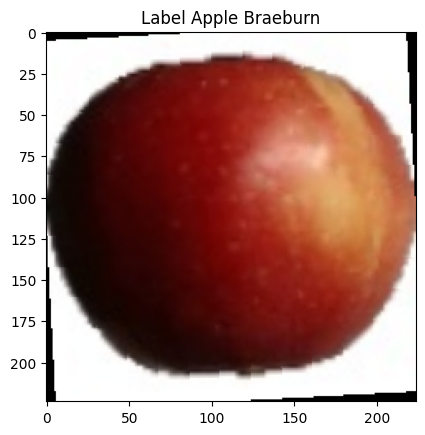

In [25]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = data_train.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

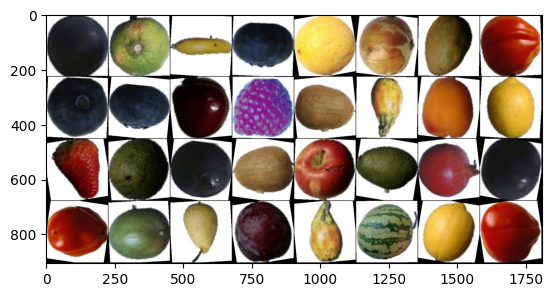

In [26]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)